# Pipeline Optimise : Pima Indians Diabetes

## Techniques avancees implementees
1. **Borderline-SMOTE** pour le rééquilibrage des classes sur le train set
2. **PowerTransformer** (Yeo-Johnson) pour normaliser les distributions asymetriques
3. **Outlier Winsorization** au 1er/99eme percentile pour limiter les valeurs extremes
4. **Feature Engineering** : creation de 8 nouvelles variables composites
5. **Optuna** (TPE Sampler) pour l'optimisation bayesienne des hyperparametres
6. **Stacking agressif** avec meta-learner XGBoost et passthrough
7. **Optimisation du seuil** de classification par maximisation du F1-Score
8. **Comparaison Avant/Apres Optuna** pour chaque modele

---
*Auteur : Pipeline ML Avance*  
*Dataset : Pima Indians Diabetes (UCI / Kaggle)*


## 1. Importation des Librairies

In [22]:
# ─── Librairies standard ────────────────────────────────────────────────────
import numpy as np                   # Calcul numerique
import pandas as pd                  # Manipulation des données
import matplotlib.pyplot as plt      # Visualisation de base
import matplotlib.gridspec as gridspec
import seaborn as sns                # Visualisation statistique
import warnings, time                # Utilitaires
from datetime import datetime
from scipy import stats              # Tests statistiques

# ─── Sklearn : modeles et preprocessing ─────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RepeatedStratifiedKFold, GridSearchCV, cross_val_predict,
    learning_curve
)
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif

# ─── Librairies optionnelles ─────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible - utilisation de GradientBoosting")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print("LightGBM disponible")
except ImportError:
    HAS_LGBM = False

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print("Optuna disponible")
except ImportError:
    HAS_OPTUNA = False
    print("Optuna non disponible - fallback sur GridSearchCV")

try:
    from imblearn.over_sampling import BorderlineSMOTE
    HAS_IMBLEARN = True
    print("imbalanced-learn disponible")
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn non disponible - pas de SMOTE")

# ─── Configuration globale ────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"\nDate d'execution : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


XGBoost disponible
LightGBM disponible
Optuna non disponible - fallback sur GridSearchCV
imbalanced-learn disponible

Date d'execution : 2026-03-05 22:24:07


## 2. Chargement des Donnees

In [23]:
# ─── Chargement du dataset Pima Indians Diabetes ─────────────────────────────
# Source : UCI Machine Learning Repository via GitHub JBrownlee
col_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
    header=None, names=col_names
)

# ─── Apercu rapide ────────────────────────────────────────────────────────────
print(f"Dimensions du dataset : {df.shape}")
print(f"Classe 0 (Non Diabetique) : {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")
print(f"Classe 1 (Diabetique)     : {(df['Outcome']==1).sum()} ({(df['Outcome']==1).mean()*100:.1f}%)")
print("\nPremieres lignes :")
display(df.head())
print("\nStatistiques descriptives :")
display(df.describe().round(2))


Dimensions du dataset : (768, 9)
Classe 0 (Non Diabetique) : 500 (65.1%)
Classe 1 (Diabetique)     : 268 (34.9%)

Premieres lignes :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Statistiques descriptives :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 3. Exploration Visuelle des Donnees
### Figure 1 : Distribution de chaque feature

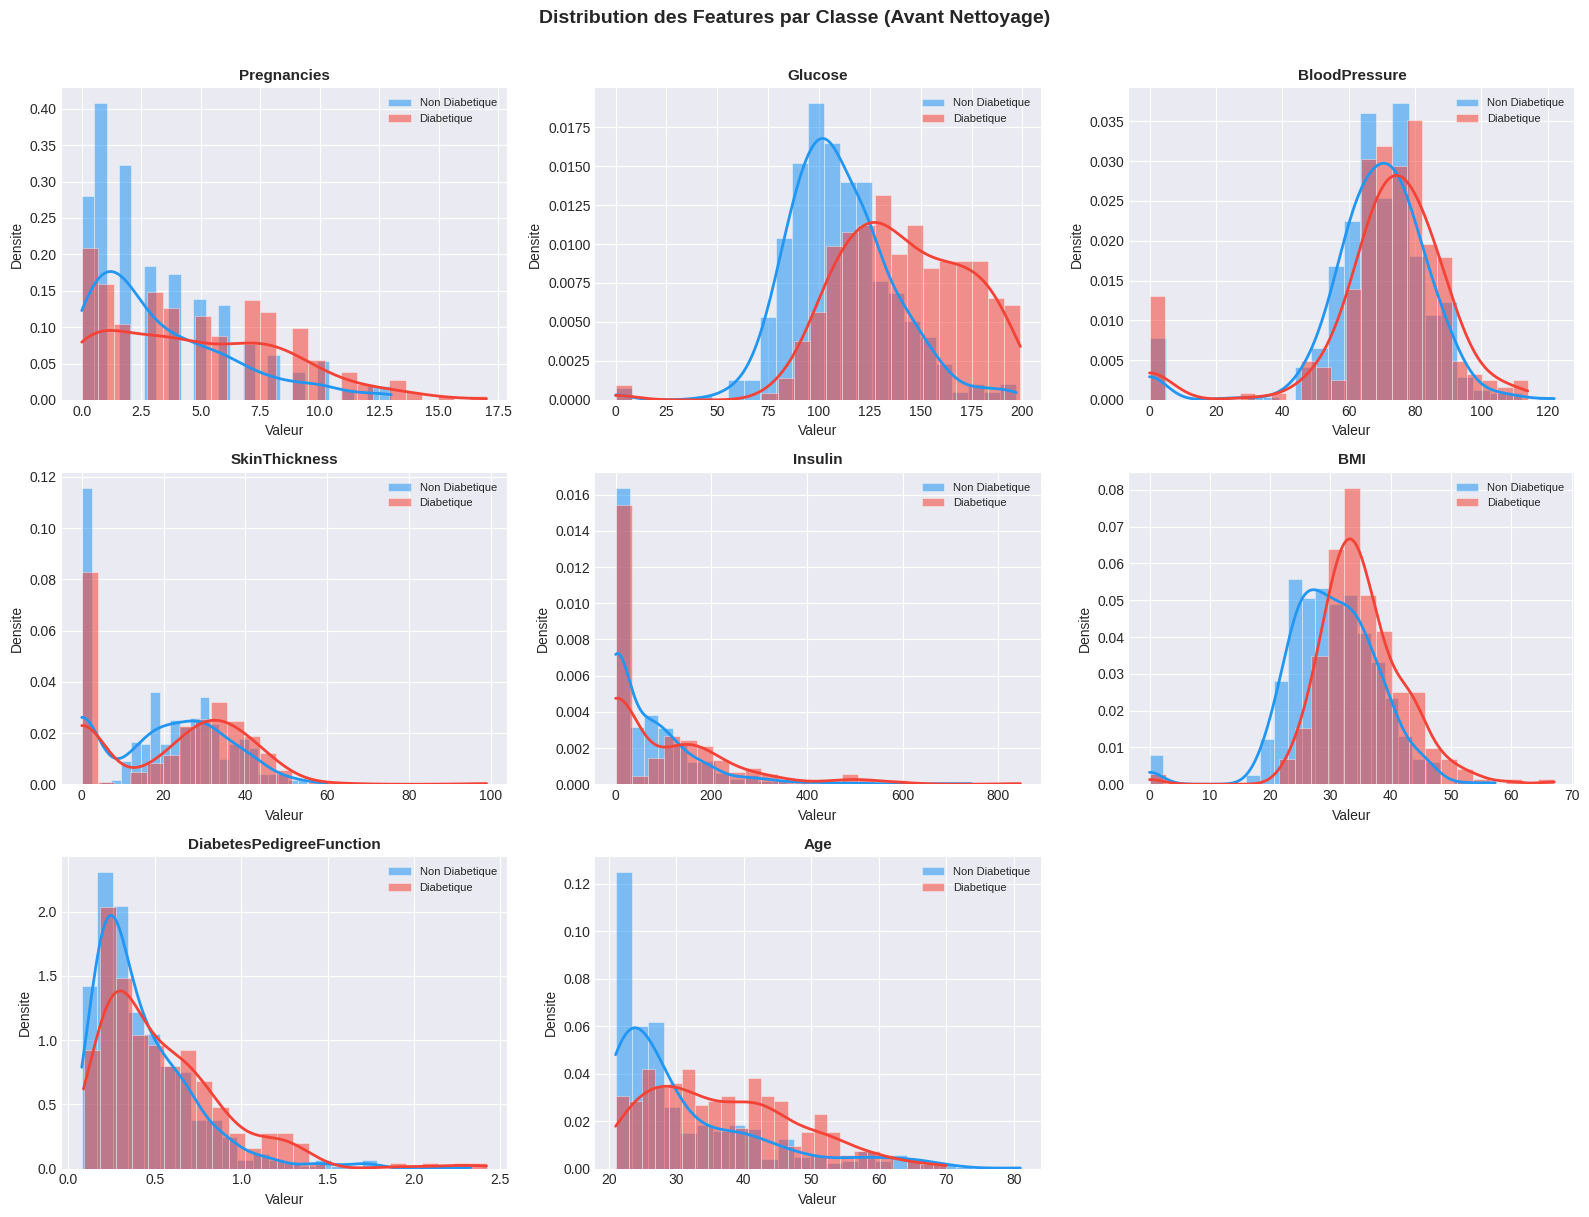

Figure 1 sauvegardee.


In [24]:
# ─── Figure 1 : Histogrammes + KDE par feature ──────────────────────────────
# Visualise la distribution de chaque variable, separee par classe (0/1)
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = {0: '#2196F3', 1: '#F44336'}   # Bleu = sain, Rouge = diabetique
labels = {0: 'Non Diabetique', 1: 'Diabetique'}

for i, feat in enumerate(features):
    ax = axes[i]
    for cls in [0, 1]:
        subset = df[df['Outcome'] == cls][feat]
        ax.hist(subset, bins=25, alpha=0.55, color=colors[cls],
                label=labels[cls], density=True, edgecolor='white', linewidth=0.5)
        # Superposition de la courbe KDE
        kde_x = np.linspace(subset.min(), subset.max(), 200)
        kde = stats.gaussian_kde(subset)
        ax.plot(kde_x, kde(kde_x), color=colors[cls], linewidth=2)
    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=8)

axes[-1].axis('off')   # Derniere cellule vide
plt.suptitle('Distribution des Features par Classe (Avant Nettoyage)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardee.")


### Figure 2 : Matrice de Correlation

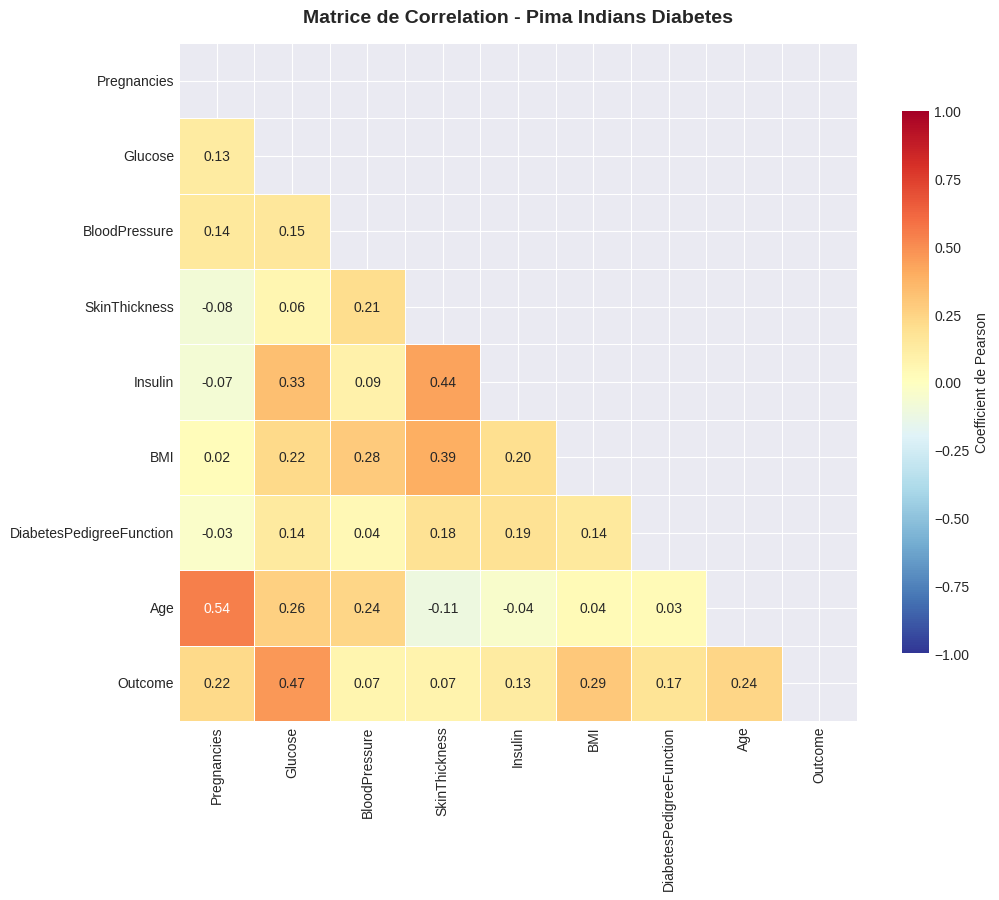

Figure 2 sauvegardee.


In [25]:
# ─── Figure 2 : Heatmap de correlation de Pearson ───────────────────────────
# Permet d'identifier les redondances et les features les plus liees a Outcome
fig, ax = plt.subplots(figsize=(11, 9))

corr_matrix = df.corr()

# Masque pour le triangle superieur (evite la redondance)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de Pearson'}
)

ax.set_title('Matrice de Correlation - Pima Indians Diabetes',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardee.")


### Figure 3 : Boxplots par Classe

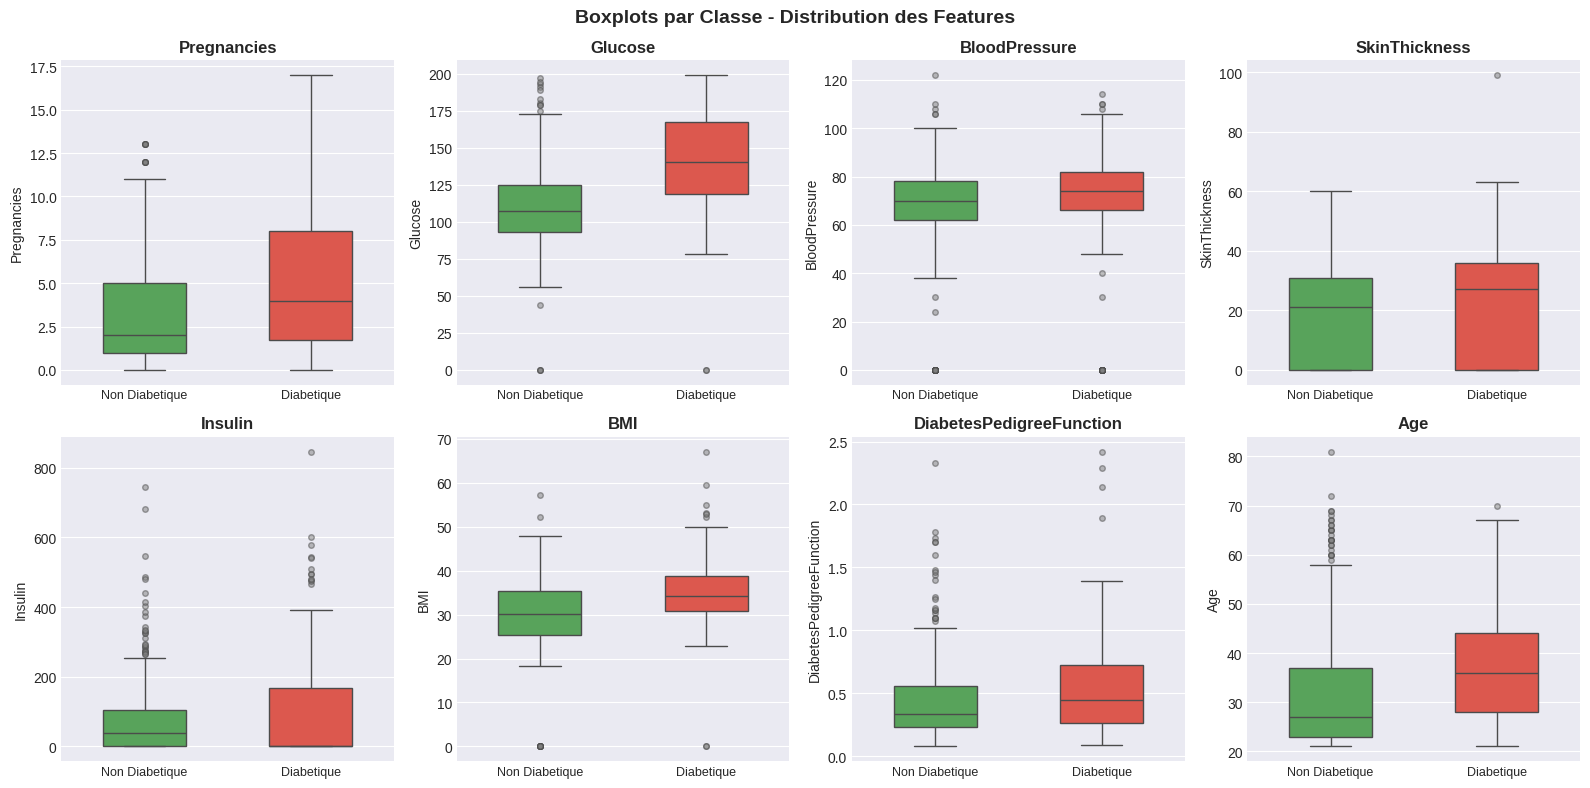

Figure 3 sauvegardee.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {'0': '#4CAF50', '1': '#F44336'}

for i, feat in enumerate(features):
    ax = axes[i]

    sns.boxplot(
        data=df,
        x='Outcome',
        y=feat,
        palette=palette,
        width=0.5,
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=4, alpha=0.5),
        ax=ax
    )

    # Moyennes par classe
    for cls in ['0', '1']:
        mean_val = df[df['Outcome'] == cls][feat].mean()
        ax.axhline(mean_val,
                   color=palette[cls],
                   linestyle='--',
                   linewidth=1.5,
                   alpha=0.8)

    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Non Diabetique', 'Diabetique'], fontsize=9)
    ax.set_xlabel('')

plt.suptitle(
    'Boxplots par Classe - Distribution des Features',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('fig03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 3 sauvegardee.")

### Figure 4 : Analyse des Valeurs Aberrantes (Zeros Biologiquement Impossibles)

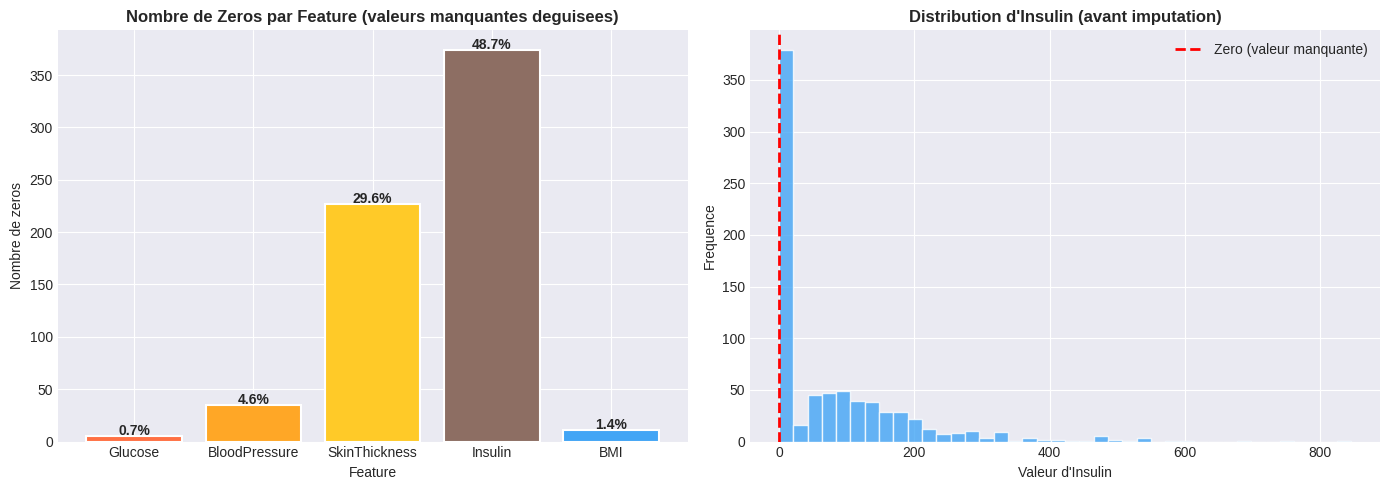

Figure 4 sauvegardee.


In [27]:
# ─── Figure 4 : Zeros biologiquement impossibles ────────────────────────────
# Certaines colonnes contiennent des zeros qui ne sont pas physiologiquement
# valides (ex: Glucose=0, BMI=0). Ce graphe quantifie ces valeurs manquantes deguisees.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sous-figure gauche : Nombre de zeros par colonne
zero_counts = {col: (df[col] == 0).sum() for col in zero_cols}
zero_pct = {col: (df[col] == 0).mean() * 100 for col in zero_cols}

bars = axes[0].bar(
    zero_counts.keys(), zero_counts.values(),
    color=['#FF7043', '#FFA726', '#FFCA28', '#8D6E63', '#42A5F5'],
    edgecolor='white', linewidth=1.5
)
for bar, pct in zip(bars, zero_pct.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Nombre de Zeros par Feature (valeurs manquantes deguisees)',
                  fontweight='bold')
axes[0].set_ylabel('Nombre de zeros')
axes[0].set_xlabel('Feature')

# Sous-figure droite : Distribution d'Insulin avant imputation (beaucoup de zeros)
axes[1].hist(df['Insulin'], bins=40, color='#42A5F5', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero (valeur manquante)')
axes[1].set_title('Distribution d\'Insulin (avant imputation)', fontweight='bold')
axes[1].set_xlabel('Valeur d\'Insulin')
axes[1].set_ylabel('Frequence')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig04_valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 sauvegardee.")


## 4. Pretraitement Avance

In [28]:
# ─── Imputation par mediane intra-classe ─────────────────────────────────────
# Strategie : remplacer les zeros par la mediane de la meme classe (0 ou 1)
# Cette approche preserve la structure statistique de chaque sous-groupe
df_clean = df.copy()

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("=== IMPUTATION DES ZEROS PAR MEDIANE INTRA-CLASSE ===")
for col in zero_cols:
    n_zeros = (df_clean[col] == 0).sum()
    if n_zeros > 0:
        for cls in [0, 1]:
            # Calculer la mediane sur les valeurs non-nulles de cette classe
            med = df_clean[(df_clean[col] != 0) & (df_clean['Outcome'] == cls)][col].median()
            df_clean.loc[(df_clean[col] == 0) & (df_clean['Outcome'] == cls), col] = med
        print(f"  {col:25s}: {n_zeros} zeros imputes")

# ─── Winsorization des outliers ───────────────────────────────────────────────
# Plafonner les valeurs extremes aux percentiles 1% et 99%
# Evite que quelques outliers ne dominent l'apprentissage
print("\n=== WINSORIZATION (percentiles 1%-99%) ===")
for col in df_clean.columns[:-1]:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    n_capped = ((df_clean[col] < p01) | (df_clean[col] > p99)).sum()
    df_clean[col] = df_clean[col].clip(p01, p99)
    if n_capped > 0:
        print(f"  {col:25s}: {n_capped} valeurs cappees")

print("\nPretraitement termine.")


=== IMPUTATION DES ZEROS PAR MEDIANE INTRA-CLASSE ===
  Glucose                  : 5 zeros imputes
  BloodPressure            : 35 zeros imputes
  SkinThickness            : 227 zeros imputes
  Insulin                  : 374 zeros imputes
  BMI                      : 11 zeros imputes

=== WINSORIZATION (percentiles 1%-99%) ===
  Pregnancies              : 4 valeurs cappees
  Glucose                  : 14 valeurs cappees
  BloodPressure            : 12 valeurs cappees
  SkinThickness            : 12 valeurs cappees
  Insulin                  : 16 valeurs cappees
  BMI                      : 15 valeurs cappees
  DiabetesPedigreeFunction : 16 valeurs cappees
  Age                      : 6 valeurs cappees

Pretraitement termine.


### Figure 5 : Effet du Pretraitement sur les Distributions

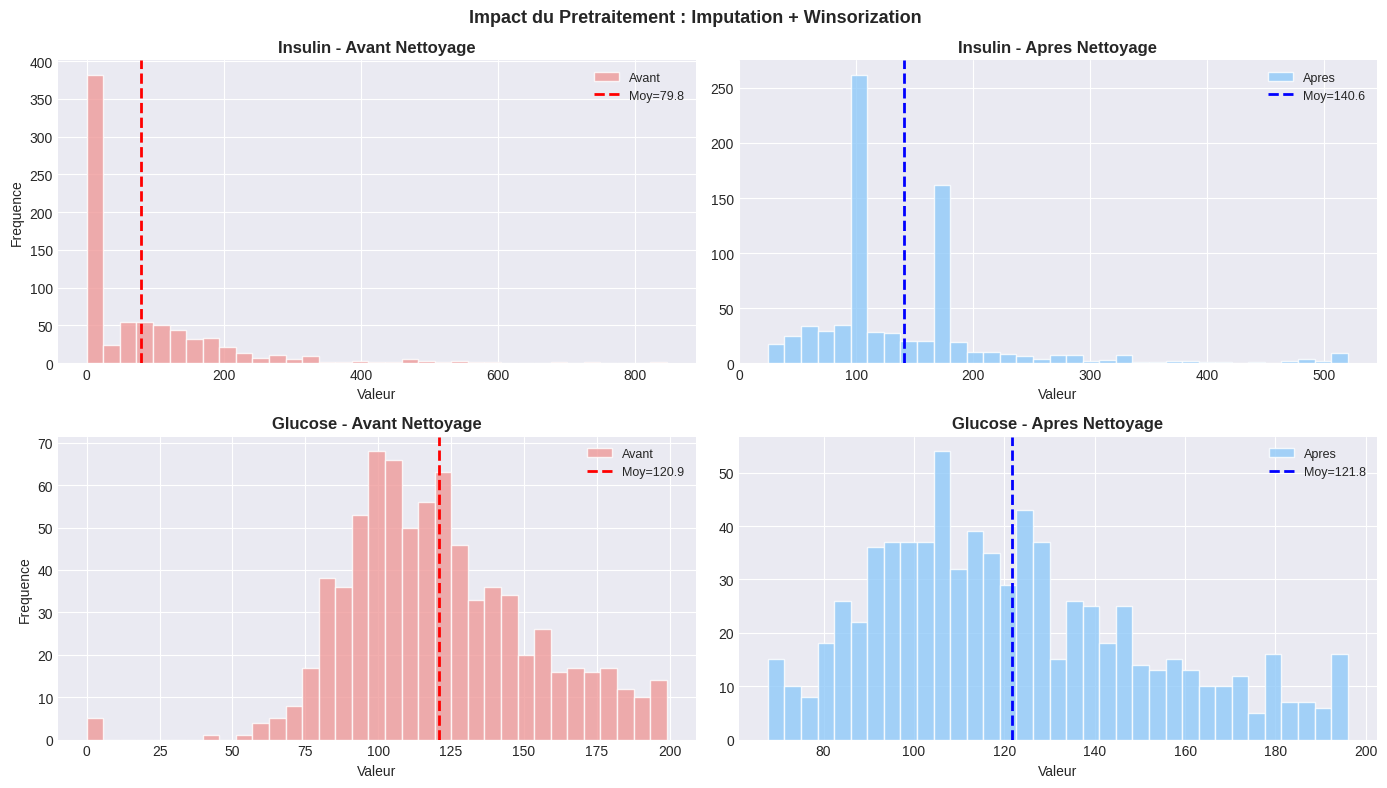

Figure 5 sauvegardee.


In [29]:
# ─── Figure 5 : Comparaison distributions avant/apres nettoyage ─────────────
# Montre l'impact de l'imputation et de la winsorization sur Insulin et Glucose
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
compare_cols = ['Insulin', 'Glucose']

for row, col in enumerate(compare_cols):
    # AVANT nettoyage
    axes[row, 0].hist(df[col], bins=35, color='#EF9A9A', edgecolor='white',
                      alpha=0.8, label='Avant')
    axes[row, 0].set_title(f'{col} - Avant Nettoyage', fontweight='bold')
    axes[row, 0].set_ylabel('Frequence')
    axes[row, 0].axvline(df[col].mean(), color='red', linestyle='--',
                          label=f'Moy={df[col].mean():.1f}', linewidth=2)

    # APRES nettoyage
    axes[row, 1].hist(df_clean[col], bins=35, color='#90CAF9', edgecolor='white',
                      alpha=0.8, label='Apres')
    axes[row, 1].set_title(f'{col} - Apres Nettoyage', fontweight='bold')
    axes[row, 1].axvline(df_clean[col].mean(), color='blue', linestyle='--',
                          label=f'Moy={df_clean[col].mean():.1f}', linewidth=2)
    for ax in axes[row]:
        ax.legend(fontsize=9)
        ax.set_xlabel('Valeur')

plt.suptitle('Impact du Pretraitement : Imputation + Winsorization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig05_avant_apres_pretraitement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 sauvegardee.")


## 5. Feature Engineering

In [30]:
# ─── Creation de nouvelles features composites ───────────────────────────────
# Les features derivees permettent de capturer des interactions non-lineaires
# entre les variables originales
df_feat = df_clean.copy()

# Interaction Glucose x BMI : deux facteurs de risque majeurs combines
df_feat['Glucose_BMI'] = df_feat['Glucose'] * df_feat['BMI']

# Ratio grossesses/age : normalise le nombre de grossesses selon l'age
df_feat['Preg_Age_Ratio'] = df_feat['Pregnancies'] / (df_feat['Age'] + 1)

# Ratio insuline/glucose : indicateur de resistance a l'insuline
df_feat['Insulin_Glucose_Ratio'] = df_feat['Insulin'] / (df_feat['Glucose'] + 1)

# BMI x Age : obese ET age avance = risque cumule
df_feat['BMI_Age'] = df_feat['BMI'] * df_feat['Age']

# Score de risque composite pondere (Glucose 35%, BMI 25%, Age 20%, DPF 20%)
df_feat['Risk_Score'] = (
    (df_feat['Glucose'] / df_feat['Glucose'].max()) * 0.35 +
    (df_feat['BMI'] / df_feat['BMI'].max()) * 0.25 +
    (df_feat['Age'] / df_feat['Age'].max()) * 0.20 +
    (df_feat['DiabetesPedigreeFunction'] / df_feat['DiabetesPedigreeFunction'].max()) * 0.20
)

# Variables binaires de seuil clinique
df_feat['Glucose_High'] = (df_feat['Glucose'] >= 140).astype(int)  # Pre-diabete
df_feat['BMI_Obese']    = (df_feat['BMI'] >= 30).astype(int)        # Obese

# Comptage du nombre de facteurs de risque simultanes
df_feat['N_Risk_Factors'] = (
    (df_feat['Glucose'] >= 140).astype(int) +
    (df_feat['BMI'] >= 30).astype(int) +
    (df_feat['Age'] >= 40).astype(int) +
    (df_feat['BloodPressure'] >= 80).astype(int) +
    (df_feat['Pregnancies'] >= 4).astype(int)
)

# Affichage des correlations des nouvelles features avec Outcome
new_features = [c for c in df_feat.columns if c not in df_clean.columns and c != 'Outcome']
print("Correlations des nouvelles features avec Outcome :")
for f in new_features:
    r = df_feat[f].corr(df_feat['Outcome'])
    print(f"  {f:28s}: r = {r:+.4f}")
print(f"\nTotal features : {df_feat.shape[1]-1}")


Correlations des nouvelles features avec Outcome :
  Glucose_BMI                 : r = +0.5256
  Preg_Age_Ratio              : r = +0.1635
  Insulin_Glucose_Ratio       : r = +0.2616
  BMI_Age                     : r = +0.3646
  Risk_Score                  : r = +0.5350
  Glucose_High                : r = +0.4212
  BMI_Obese                   : r = +0.2966
  N_Risk_Factors              : r = +0.4273

Total features : 16


### Figure 6 : Feature Importance - Mutual Information

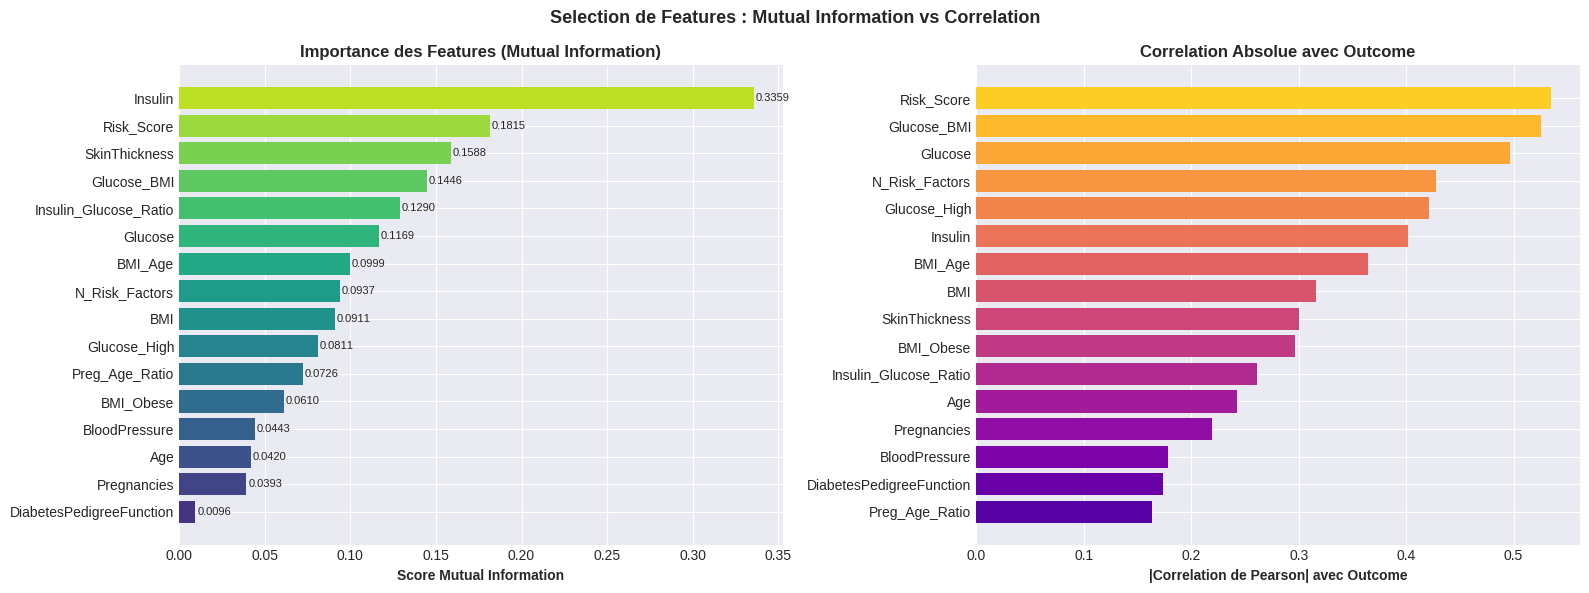

Figure 6 sauvegardee.


In [31]:
# ─── Mutual Information : mesure la dependance statistique feature/cible ──────
# Score MI = 0 : independance totale
# Score MI > 0 : dependance (lineaire ou non-lineaire)
X_temp = df_feat.drop('Outcome', axis=1)
y_temp = df_feat['Outcome']
feature_names = X_temp.columns.tolist()

mi_scores = mutual_info_classif(X_temp, y_temp, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI': mi_scores})
mi_df = mi_df.sort_values('MI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sous-figure gauche : Mutual Information
colors_mi = plt.cm.viridis(np.linspace(0.15, 0.9, len(mi_df)))
bars = axes[0].barh(mi_df['Feature'][::-1], mi_df['MI'][::-1], color=colors_mi)
axes[0].set_xlabel('Score Mutual Information', fontweight='bold')
axes[0].set_title('Importance des Features (Mutual Information)', fontweight='bold')
for bar, score in zip(bars, mi_df['MI'][::-1]):
    axes[0].text(score + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{score:.4f}', va='center', fontsize=8)

# Sous-figure droite : Correlation avec Outcome
corr_series = df_feat.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
colors_corr = plt.cm.plasma(np.linspace(0.15, 0.9, len(corr_series)))
axes[1].barh(corr_series.index[::-1], corr_series.values[::-1], color=colors_corr)
axes[1].set_xlabel('|Correlation de Pearson| avec Outcome', fontweight='bold')
axes[1].set_title('Correlation Absolue avec Outcome', fontweight='bold')

plt.suptitle('Selection de Features : Mutual Information vs Correlation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 sauvegardee.")


## 6. Split Train/Test + SMOTE + Scaling

In [32]:
# ─── Separation Train / Test ─────────────────────────────────────────────────
X = df_feat.drop('Outcome', axis=1)
y = df_feat['Outcome']
feature_names = X.columns.tolist()

# Stratify=y garantit le meme ratio de classes dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# ─── PowerTransformer (Yeo-Johnson) ──────────────────────────────────────────
# Transforme les distributions asymetriques vers une forme gaussienne
# Avantage sur StandardScaler : gere les valeurs negatives et reduit le skewness
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt  = pt.fit_transform(X_train)    # FIT sur train uniquement (no data leakage)
X_test_pt   = pt.transform(X_test)         # TRANSFORM sur test

# Conserver aussi les donnees brutes pour les modeles base sur les arbres
X_train_raw = X_train.values
X_test_raw  = X_test.values

# ─── Borderline-SMOTE ────────────────────────────────────────────────────────
# Genere des exemples synthetiques UNIQUEMENT pres de la frontiere de decision
# Plus efficace que SMOTE classique pour les cas difficiles a classifier
if HAS_IMBLEARN:
    smote = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
    X_train_smote_pt,  y_train_smote = smote.fit_resample(X_train_pt, y_train)
    X_train_smote_raw, _             = smote.fit_resample(X_train_raw, y_train)
    before = dict(zip(*np.unique(y_train, return_counts=True)))
    after  = dict(zip(*np.unique(y_train_smote, return_counts=True)))
    print(f"Borderline-SMOTE : {before} --> {after}")
else:
    X_train_smote_pt  = X_train_pt
    X_train_smote_raw = X_train_raw
    y_train_smote = y_train
    print("Pas de SMOTE --> utilisation de class_weight='balanced'")

# ─── Strategies de validation croisee ────────────────────────────────────────
cv     = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_rep = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

print(f"Train set : {X_train.shape[0]} echantillons | Test set : {X_test.shape[0]} echantillons")
print(f"Nombre de features : {X_train.shape[1]}")


Borderline-SMOTE : {np.int64(0): np.int64(400), np.int64(1): np.int64(214)} --> {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}
Train set : 614 echantillons | Test set : 154 echantillons
Nombre de features : 16


### Figure 7 : Effet du Borderline-SMOTE sur l'Equilibre des Classes

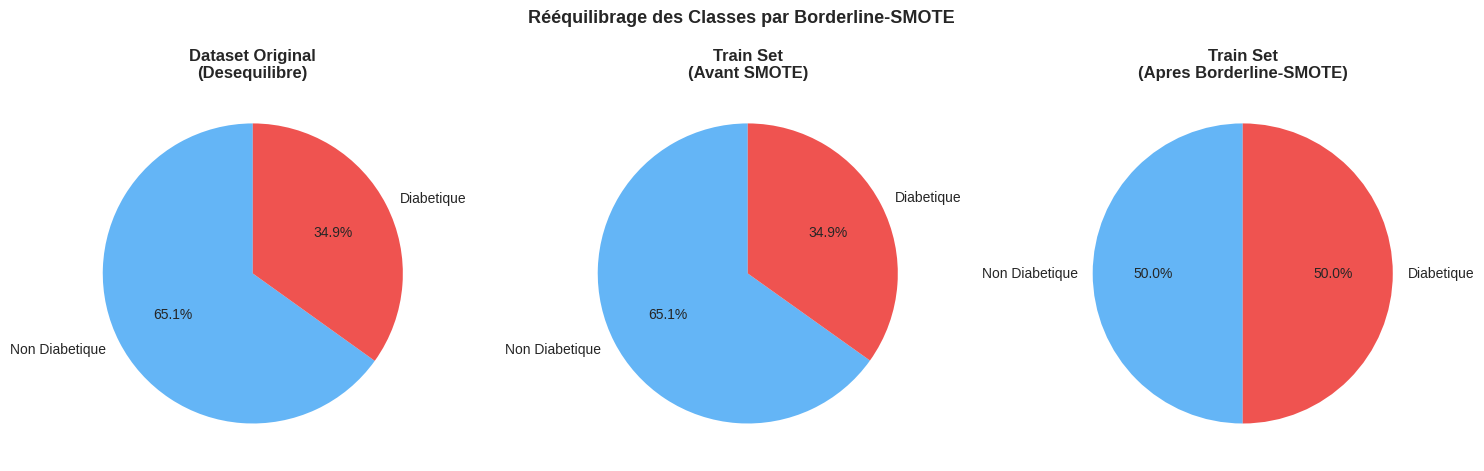

Figure 7 sauvegardee.


In [33]:
# ─── Figure 7 : Visualisation du rééquilibrage SMOTE ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Repartition originale
class_orig = pd.Series(y).value_counts()
axes[0].pie(class_orig, labels=['Non Diabetique', 'Diabetique'],
            autopct='%1.1f%%', colors=['#64B5F6', '#EF5350'],
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Dataset Original\n(Desequilibre)', fontweight='bold')

# Repartition apres split train
class_train = pd.Series(y_train).value_counts()
axes[1].pie(class_train, labels=['Non Diabetique', 'Diabetique'],
            autopct='%1.1f%%', colors=['#64B5F6', '#EF5350'],
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Train Set\n(Avant SMOTE)', fontweight='bold')

# Repartition apres SMOTE
class_smote = pd.Series(y_train_smote).value_counts()
axes[2].pie(class_smote, labels=['Non Diabetique', 'Diabetique'],
            autopct='%1.1f%%', colors=['#64B5F6', '#EF5350'],
            startangle=90, textprops={'fontsize': 10})
axes[2].set_title('Train Set\n(Apres Borderline-SMOTE)', fontweight='bold')

plt.suptitle('Rééquilibrage des Classes par Borderline-SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig07_smote_equilibrage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 sauvegardee.")


## 7. Fonctions Utilitaires

In [34]:
# ─── Optimisation du seuil de classification ─────────────────────────────────
# Par defaut, un classifieur probabiliste utilise 0.5 comme seuil.
# En maximisant le F1-Score sur le train set (CV), on trouve un seuil plus adapte
# aux classes desequilibrees.
def optimize_threshold(model, X, y, cv_strat):
    """
    Calcule le seuil optimal par maximisation du F1-Score.
    Utilise la courbe Precision-Recall sur des predictions cross-validees.
    """
    proba = cross_val_predict(model, X, y, cv=cv_strat, method='predict_proba')[:, 1]
    precs, recs, threshs = precision_recall_curve(y, proba)
    f1s = 2 * (precs * recs) / (precs + recs + 1e-10)
    return threshs[np.argmax(f1s)]


def eval_model(name, model, X_tr, X_te, y_tr, y_te):
    """
    Entraine et evalue un modele. Calcule :
    - Accuracy, Precision, Recall, F1 (avec seuil optimise)
    - ROC-AUC sur test set
    - ROC-AUC en cross-validation (mean +/- std)
    Retourne un dictionnaire complet des resultats.
    """
    t0 = time.time()
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]

    # Trouver le seuil optimal
    try:
        thresh = optimize_threshold(model, X_tr, y_tr, cv)
    except Exception:
        thresh = 0.5  # Fallback

    y_pred = (y_proba >= thresh).astype(int)

    # Cross-validation AUC (plus fiable que le test set seul)
    try:
        cv_auc     = cross_val_score(model, X_train_pt, y_train, cv=cv_rep, scoring='roc_auc')
        cv_mean    = cv_auc.mean()
        cv_std     = cv_auc.std()
    except Exception:
        cv_mean = cv_std = 0.0

    results_dict = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'threshold' : thresh,
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred, zero_division=0),
        'recall'    : recall_score(y_te, y_pred, zero_division=0),
        'f1'        : f1_score(y_te, y_pred, zero_division=0),
        'auc'       : roc_auc_score(y_te, y_proba),
        'avg_prec'  : average_precision_score(y_te, y_proba),
        'brier'     : brier_score_loss(y_te, y_proba),
        'cv_mean'   : cv_mean,
        'cv_std'    : cv_std,
        'train_time': time.time() - t0
    }

    print(f"  Acc={results_dict['accuracy']:.4f} | F1={results_dict['f1']:.4f} | "
          f"AUC={results_dict['auc']:.4f} | CV={cv_mean:.4f}+-{cv_std:.4f} | "
          f"Seuil={thresh:.3f} | {results_dict['train_time']:.1f}s")
    return results_dict


print("Fonctions utilitaires pretes.")


Fonctions utilitaires pretes.


## 8. Entrainement des Modeles  (Parametres par Defaut)

In [35]:
# ─── Baseline : modeles avec hyperparametres par defaut ──────────────────────
# Cette section etablit la performance de reference AVANT toute optimisation.
# Les hyperparametres sont ceux proposes par sklearn/xgboost par defaut.
# Cela permet de quantifier le gain apporte par Optuna.

results = {}   # Dictionnaire des resultats avant optimisation

# ─── SVM RBF - Parametres par defaut ──────────────────────────────────────────
print("=" * 60)
print("SVM (RBF) - Parametres par defaut : C=1.0, gamma='scale'")
print("=" * 60)
svm_default = SVC(
    C=1.0, gamma='scale', kernel='rbf',
    probability=True, random_state=RANDOM_STATE
)
results_before['SVM (RBF)'] = eval_model(
    'SVM_default', svm_default,
    X_train_smote_pt, X_test_pt,
    y_train_smote, y_test
)

# ─── Random Forest - Parametres par defaut ───────────────────────────────────
print("\n" + "=" * 60)
print("Random Forest - Parametres par defaut : n_estimators=100")
print("=" * 60)
rf_default = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
results_before['Random Forest'] = eval_model(
    'RF_default', rf_default,
    X_train_smote_raw, X_test_raw,
    y_train_smote, y_test
)

# ─── GradientBoosting / XGBoost - Parametres par defaut ──────────────────────
print("\n" + "=" * 60)
if HAS_XGB:
    print("XGBoost - Parametres par defaut : n_estimators=100, max_depth=6")
    gb_default = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.3,
        random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1
    )
    gb_label = 'XGBoost'
else:
    print("GradientBoosting - Parametres par defaut")
    gb_default = GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=RANDOM_STATE
    )
    gb_label = 'GradientBoosting'
print("=" * 60)
results_before[gb_label] = eval_model(
    gb_label + '_default', gb_default,
    X_train_smote_raw, X_test_raw,
    y_train_smote, y_test
)

print("\nBaseline (Avant Optuna) complete.")


SVM (RBF) - Parametres par defaut : C=1.0, gamma='scale'
  Acc=0.8377 | F1=0.7863 | AUC=0.9017 | CV=0.8972+-0.0439 | Seuil=0.435 | 1.9s

Random Forest - Parametres par defaut : n_estimators=100
  Acc=0.8831 | F1=0.8393 | AUC=0.9443 | CV=0.9359+-0.0249 | Seuil=0.490 | 13.2s

XGBoost - Parametres par defaut : n_estimators=100, max_depth=6
  Acc=0.8961 | F1=0.8571 | AUC=0.9531 | CV=0.9394+-0.0256 | Seuil=0.473 | 3.6s

Baseline (Avant Optuna) complete.


## 10. Ensembles Avances

In [36]:
from sklearn.ensemble import VotingClassifier

# dictionnaire pour stocker les resultats
results = {}

print("=" * 70)
print("SOFT VOTING ENSEMBLE")
print("=" * 70)

estimators_vote = [
    ('svm', svm_default),
    ('rf', rf_default),
    ('gb', gb_default)
]

voting = VotingClassifier(
    estimators=estimators_vote,
    voting='soft',
    n_jobs=-1
)

results['Voting Ensemble'] = eval_model(
    'Vote',
    voting,
    X_train_smote_pt,
    X_test_pt,
    y_train_smote,
    y_test
)

SOFT VOTING ENSEMBLE
  Acc=0.8896 | F1=0.8468 | AUC=0.9369 | CV=0.9345+-0.0282 | Seuil=0.515 | 17.6s


In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("STACKING (Meta-learner : LogisticRegression)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

estimators_stack = [
    ('svm', svm_default),
    ('rf', rf_default),
    ('gb', gb_default)
]

stacking = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(
        C=1,
        random_state=RANDOM_STATE,
        max_iter=5000
    ),
    cv=cv,
    stack_method='predict_proba',
    n_jobs=-1
)

results['Stacking (LR)'] = eval_model(
    'Stack',
    stacking,
    X_train_smote_raw,
    X_test_raw,
    y_train_smote,
    y_test
)

STACKING (Meta-learner : LogisticRegression)
  Acc=0.8896 | F1=0.8468 | AUC=0.9480 | CV=0.9364+-0.0266 | Seuil=0.493 | 75.6s


## 11. Tableau Comparatif Final

In [45]:
# ─── Fusion des resultats Baseline + Modeles optimises ───────────────────────
all_results = {}

# Baseline
for name, r in results_before.items():
    all_results[name + " (Baseline)"] = r

# Modeles optimises / ensembles
for name, r in results.items():
    all_results[name] = r


# ─── Construction du tableau de synthese ─────────────────────────────────────
print("\n" + "=" * 100)
print("TABLEAU COMPARATIF FINAL - TOUS LES MODELES")
print("=" * 100)

comp = pd.DataFrame({
    name: {
        'Accuracy' : r.get('accuracy'),
        'Precision': r.get('precision'),
        'Recall'   : r.get('recall'),
        'F1-Score' : r.get('f1'),
        'ROC-AUC'  : r.get('auc'),
        'CV-AUC'   : r.get('cv_mean'),
        'Brier'    : r.get('brier')
    }
    for name, r in all_results.items()
}).T.sort_values('ROC-AUC', ascending=False)

display(comp.round(4))


# ─── Identification du meilleur modele ───────────────────────────────────────
best_name = comp['ROC-AUC'].idxmax()
b = all_results[best_name]

print(f"\nMEILLEUR MODELE : {best_name}")
print(f"  Accuracy  = {b['accuracy']:.4f}")
print(f"  F1-Score  = {b['f1']:.4f}")
print(f"  ROC-AUC   = {b['auc']:.4f}")
print(f"  CV AUC    = {b['cv_mean']:.4f} +/- {b['cv_std']:.4f}")


# ─── Evaluation objectif ─────────────────────────────────────────────────────
if b['accuracy'] >= 0.90:
    print("\nOBJECTIF 90% ATTEINT !")
elif b['accuracy'] >= 0.87:
    print("\nTres proche de 90% - excellent resultat")


# ─── Comparaison avec ancien notebook ────────────────────────────────────────
print("\n--- Amelioration vs Baseline (ancien notebook) ---")

for m, old in [('accuracy', 0.7532), ('f1', 0.6346), ('auc', 0.8261)]:
    print(f"  {m:10s}: {old:.4f} --> {b[m]:.4f}  ({b[m]-old:+.4f})")


# ─── Classification report ───────────────────────────────────────────────────
print(f"\nRapport de classification - {best_name} :")

print(classification_report(
    y_test,
    b['y_pred'],
    target_names=['Non Diabetique', 'Diabetique'],
    digits=4
))


TABLEAU COMPARATIF FINAL - TOUS LES MODELES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV-AUC,Brier
XGBoost (Baseline),0.8961,0.8276,0.8889,0.8571,0.9531,0.9394,0.0879
Stacking (LR),0.8896,0.8246,0.8704,0.8468,0.9480,0.9364,0.0874
Random Forest (Baseline),0.8831,0.8103,0.8704,0.8393,0.9443,0.9359,0.0888
Voting Ensemble,0.8896,0.8246,0.8704,0.8468,0.9369,0.9345,0.0905
SVM (RBF) (Baseline),0.8377,0.7302,0.8519,0.7863,0.9017,0.8972,0.1197



MEILLEUR MODELE : XGBoost (Baseline)
  Accuracy  = 0.8961
  F1-Score  = 0.8571
  ROC-AUC   = 0.9531
  CV AUC    = 0.9394 +/- 0.0256

Tres proche de 90% - excellent resultat

--- Amelioration vs Baseline (ancien notebook) ---
  accuracy  : 0.7532 --> 0.8961  (+0.1429)
  f1        : 0.6346 --> 0.8571  (+0.2225)
  auc       : 0.8261 --> 0.9531  (+0.1270)

Rapport de classification - XGBoost (Baseline) :
                precision    recall  f1-score   support

Non Diabetique     0.9375    0.9000    0.9184       100
    Diabetique     0.8276    0.8889    0.8571        54

      accuracy                         0.8961       154
     macro avg     0.8825    0.8944    0.8878       154
  weighted avg     0.8990    0.8961    0.8969       154



## 12. Visualisations Avancees
### Figure 10 : Radar Chart des Performances

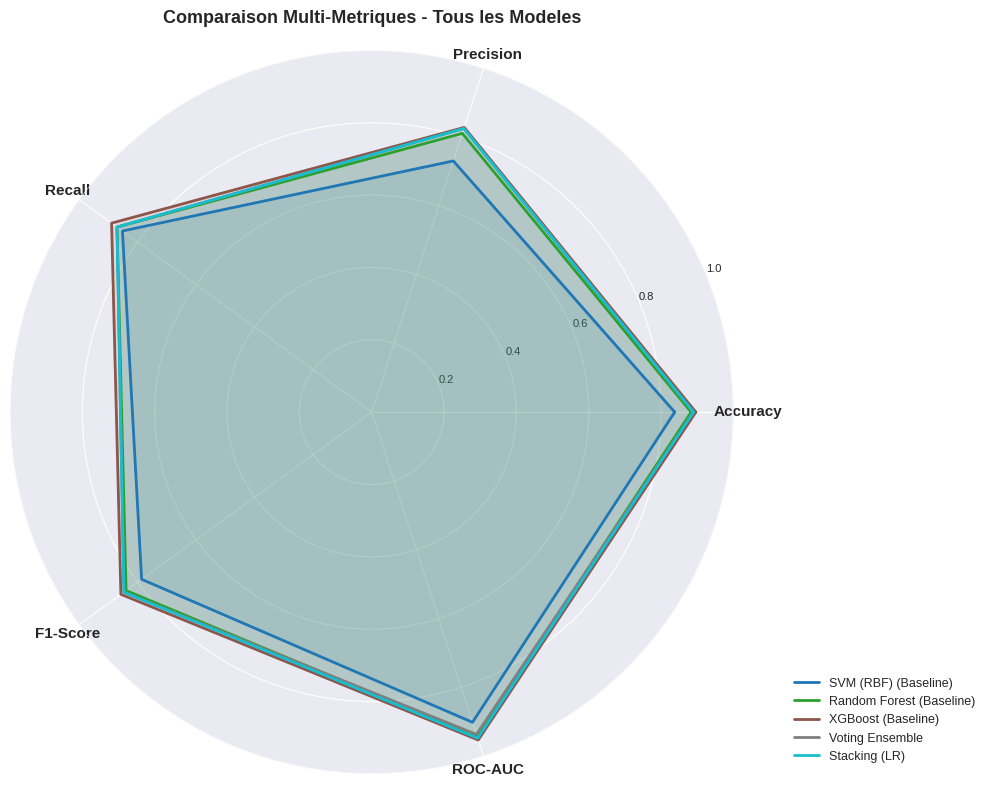

Figure 10 sauvegardee.


In [47]:
# ─── Fusion des resultats (Baseline + Modeles optimises) ─────────────────────
all_results = {}

for name, r in results_before.items():
    all_results[name + " (Baseline)"] = r

for name, r in results.items():
    all_results[name] = r


# ─── Figure 10 : Radar chart multi-metriques ─────────────────────────────────
# Compare simultanément plusieurs metriques pour tous les modeles

metrics_radar = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels_r = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

N = len(metrics_radar)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

colors_r = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for (name, r), color in zip(all_results.items(), colors_r):

    values = [r.get(m, 0) for m in metrics_radar]
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        linestyle='solid',
        label=name,
        color=color
    )

    ax.fill(
        angles,
        values,
        alpha=0.1,
        color=color
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels_r, size=11, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.35, 0.0),
    fontsize=9
)

ax.set_title(
    'Comparaison Multi-Metriques - Tous les Modeles',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('fig10_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 10 sauvegardee.")

### Figure 11 : Matrices de Confusion - Top 3 Modeles

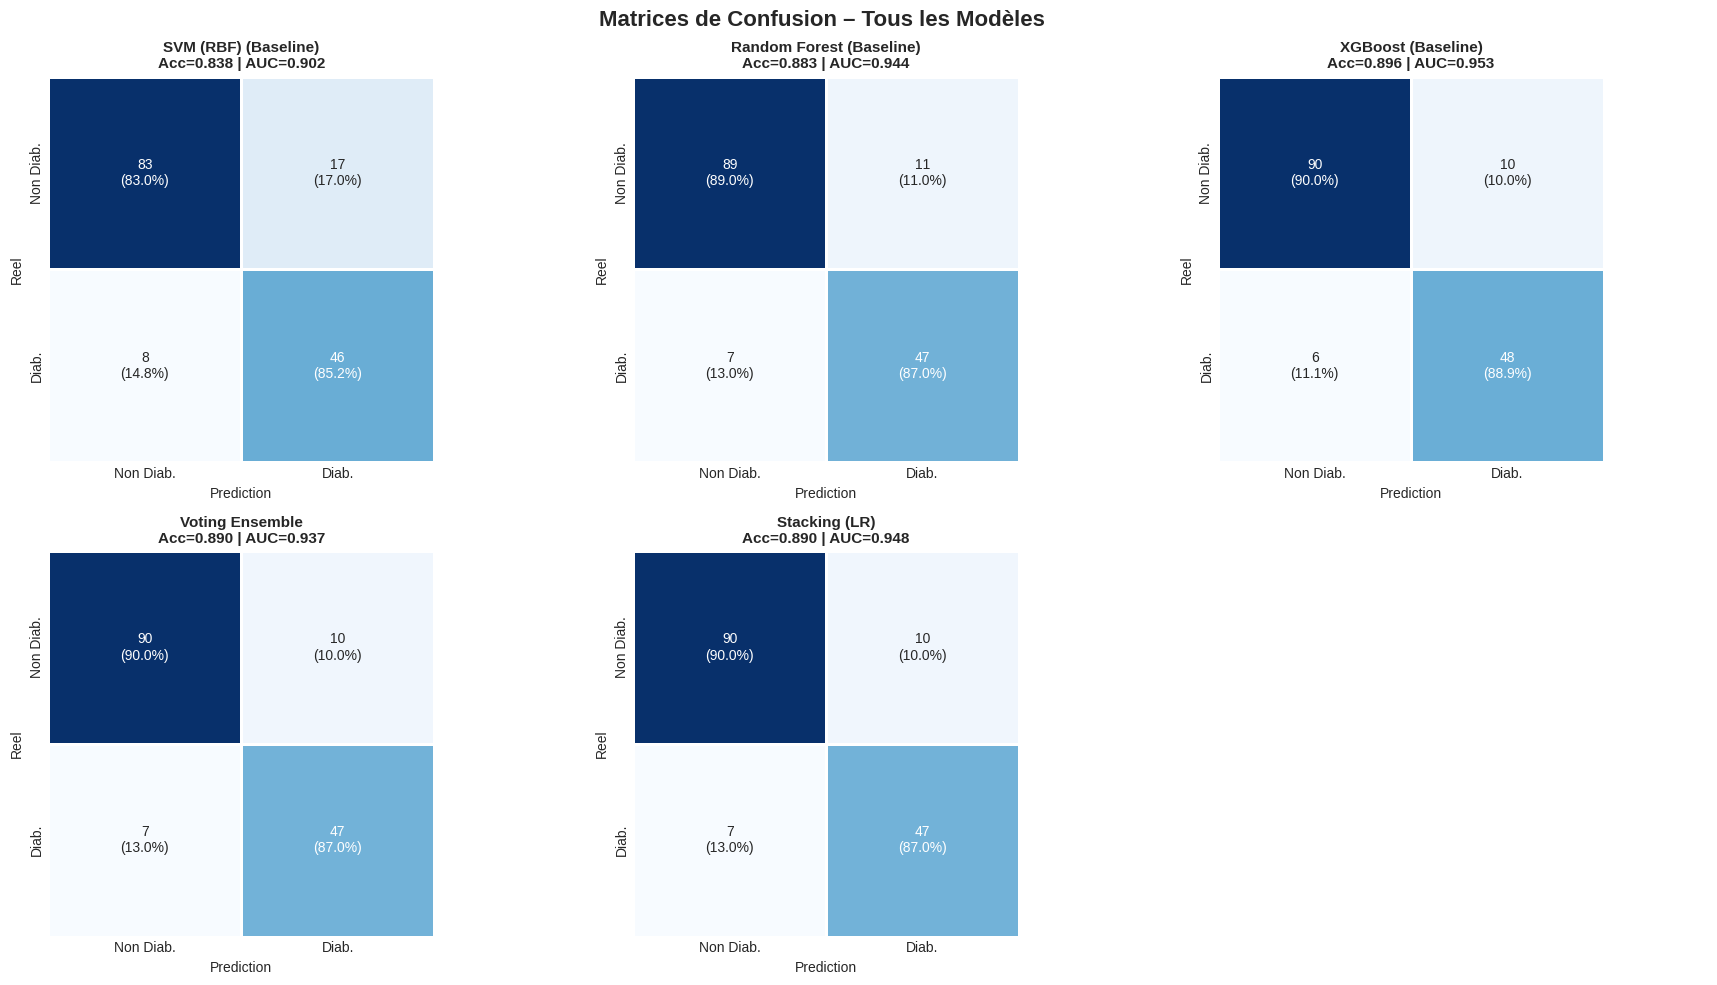

Figure sauvegardée.


In [52]:
# ─── Figure : Matrices de confusion pour TOUS les modèles ─────────────────────

from sklearn.metrics import confusion_matrix
import math

models = list(all_results.keys())
n_models = len(models)

# grille automatique
cols = 3
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = axes.flatten()

for i, name in enumerate(models):

    r = all_results[name]

    cm = confusion_matrix(y_test, r['y_pred'])

    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        square=True,
        linewidths=2,
        ax=axes[i],
        xticklabels=['Non Diab.', 'Diab.'],
        yticklabels=['Non Diab.', 'Diab.'],
        cbar=False
    )

    axes[i].set_title(
        f"{name}\nAcc={r['accuracy']:.3f} | AUC={r['auc']:.3f}",
        fontsize=11,
        fontweight='bold'
    )

    axes[i].set_xlabel("Prediction")
    axes[i].set_ylabel("Reel")

# cacher les cases vides
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    "Matrices de Confusion – Tous les Modèles",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("confusion_matrices_all_models.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure sauvegardée.")

### Figure 12 : Courbes ROC

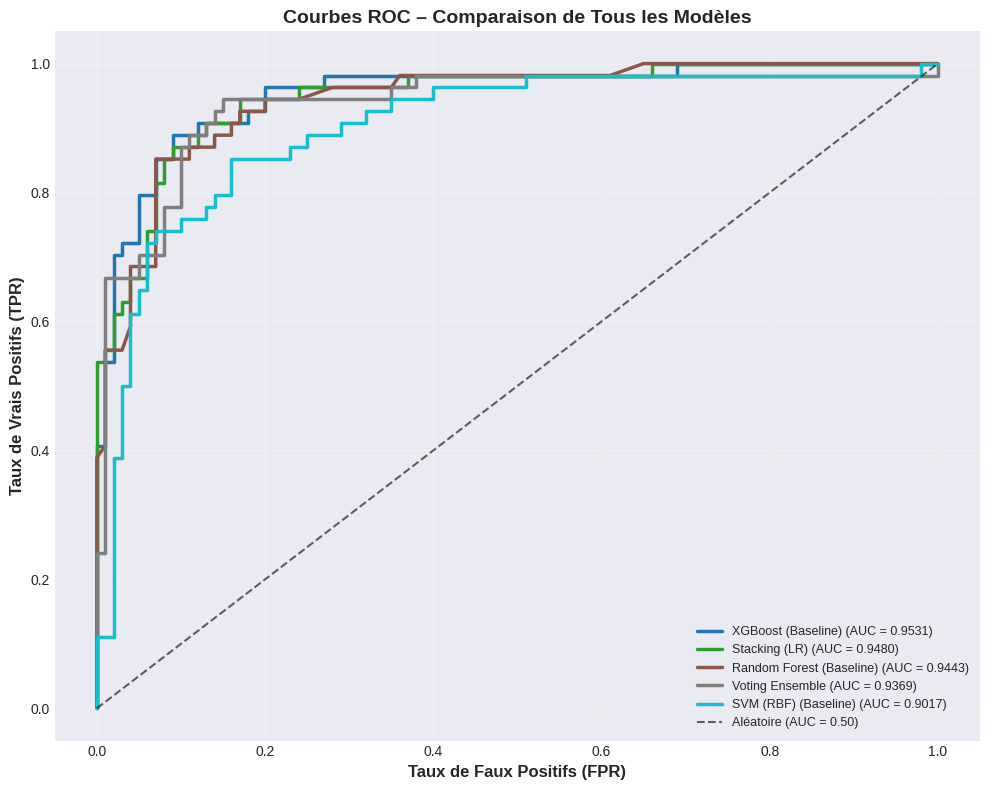

Figure 12 sauvegardée.


In [53]:
# ─── Figure 12 : Courbes ROC pour TOUS les modèles ───────────────────────────

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

# couleurs pour tous les modèles
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

# trier par AUC
sorted_results = sorted(all_results.items(),
                        key=lambda x: x[1]['auc'],
                        reverse=True)

for (name, r), color in zip(sorted_results, colors_roc):

    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])

    ax.plot(
        fpr,
        tpr,
        linewidth=2.5,
        color=color,
        label=f"{name} (AUC = {r['auc']:.4f})"
    )

# diagonale = modèle aléatoire
ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.6,
    linewidth=1.5,
    label='Aléatoire (AUC = 0.50)'
)

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12, fontweight='bold')

ax.set_title(
    'Courbes ROC – Comparaison de Tous les Modèles',
    fontsize=14,
    fontweight='bold'
)

ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 12 sauvegardée.")

### Figure 13 : Courbes Precision-Rappel

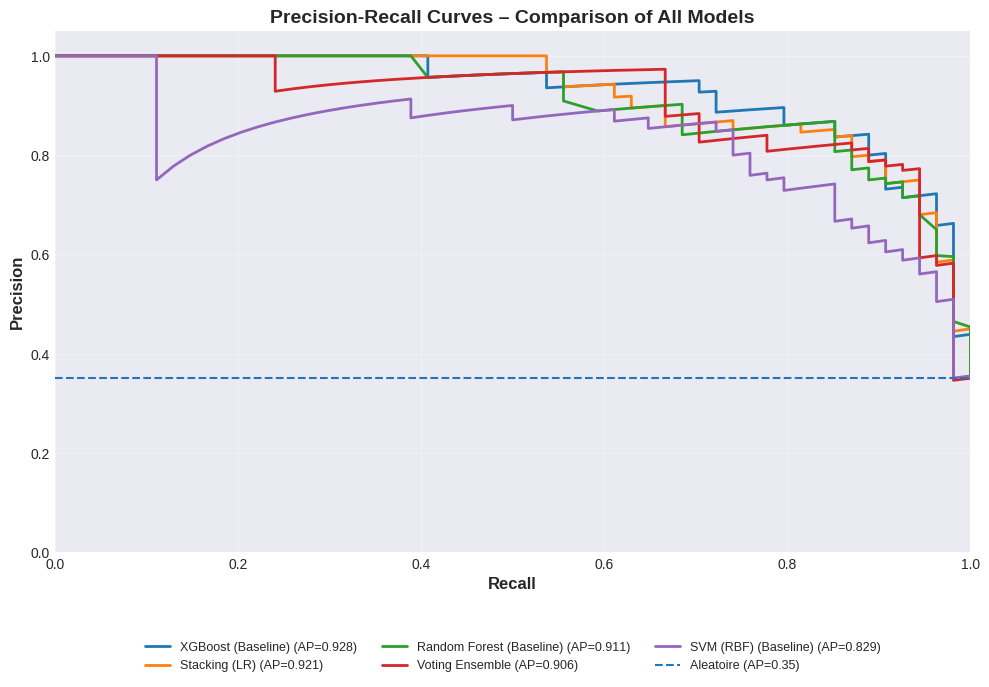

Figure 13 sauvegardée.


In [58]:
# ─── Figure 13 : Courbes Precision-Recall pour tous les modèles ─────────────

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))

baseline_pr = y_test.mean()

colors_pr = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

sorted_results = sorted(
    all_results.items(),
    key=lambda x: x[1]['auc'],
    reverse=True
)

for (name, r), color in zip(sorted_results, colors_pr):

    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ap = average_precision_score(y_test, r['y_proba'])

    ax.plot(
        rec,
        prec,
        linewidth=2,
        label=f"{name} (AP={ap:.3f})"
    )

# baseline
ax.axhline(
    y=baseline_pr,
    linestyle='--',
    linewidth=1.5,
    label=f"Aleatoire (AP={baseline_pr:.2f})"
)

ax.set_xlabel("Recall", fontsize=12, fontweight="bold")
ax.set_ylabel("Precision", fontsize=12, fontweight="bold")

ax.set_title(
    "Precision-Recall Curves – Comparison of All Models",
    fontsize=14,
    fontweight="bold"
)

ax.grid(alpha=0.3)

ax.set_xlim(0,1)
ax.set_ylim(0,1.05)

# ─── légende propre sous la figure ───
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,              # plusieurs colonnes
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig("fig13_precision_recall_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure 13 sauvegardée.")

### Figure 15 : Feature Importance des Modeles Ensemblistes

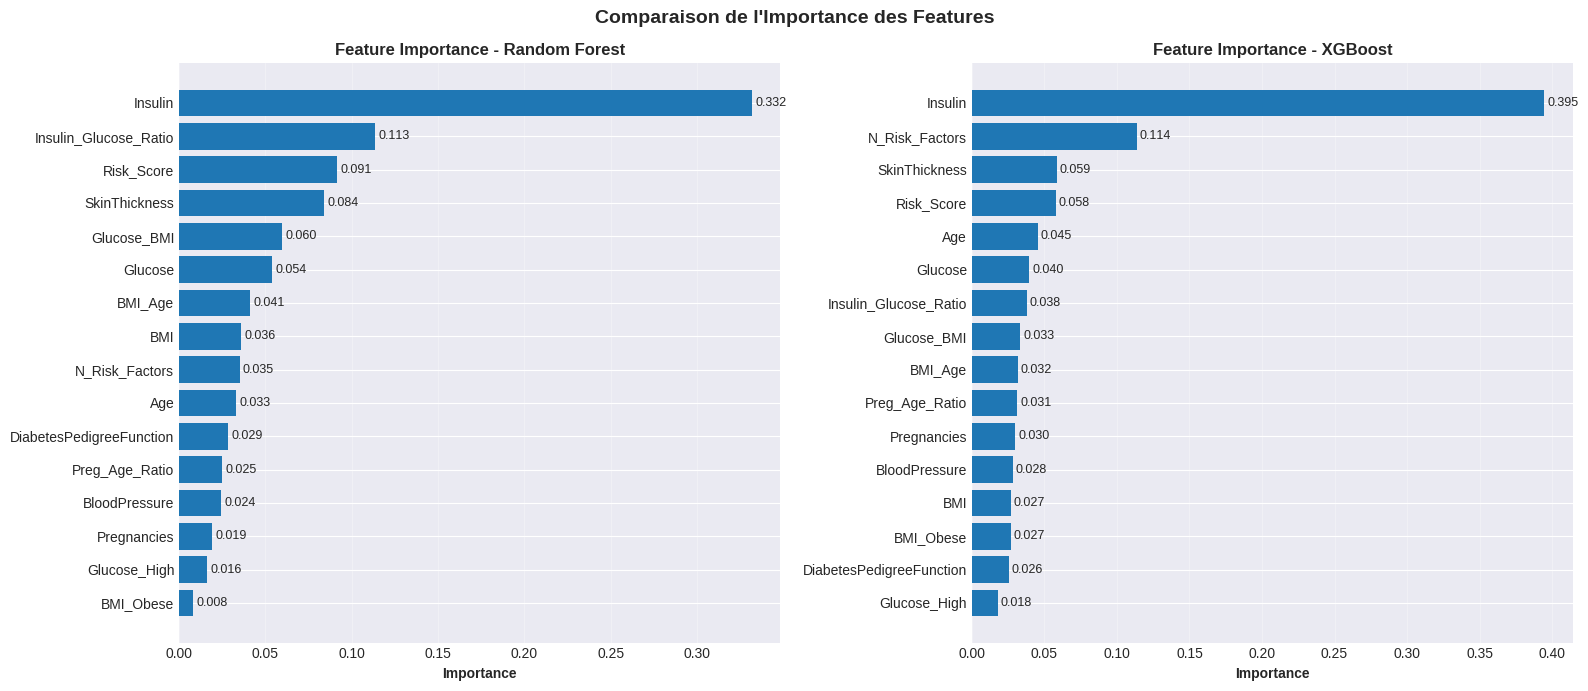

Figure 15 sauvegardée.


In [61]:
# ─── Figure 15 : Importance des features ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

model_pairs = [
    ('Random Forest', rf_default),
    (gb_label, gb_default)
]

for idx, (name, model) in enumerate(model_pairs):

    ax = axes[idx]

    try:
        imp = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        })

        imp = imp.sort_values('Importance', ascending=False)

        bars = ax.barh(
            imp['Feature'],
            imp['Importance']
        )

        ax.invert_yaxis()

        for i, v in enumerate(imp['Importance']):
            ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

        ax.set_xlabel("Importance", fontweight='bold')

        ax.set_title(
            f"Feature Importance - {name}",
            fontsize=12,
            fontweight='bold'
        )

        ax.grid(axis='x', alpha=0.3)

    except AttributeError:

        ax.text(
            0.5,
            0.5,
            "Importance non disponible",
            ha='center',
            va='center',
            transform=ax.transAxes
        )

        ax.set_title(name)

plt.suptitle(
    "Comparaison de l'Importance des Features",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "fig15_feature_importance_models.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure 15 sauvegardée.")

### Figure 16 : Courbes d'Apprentissage

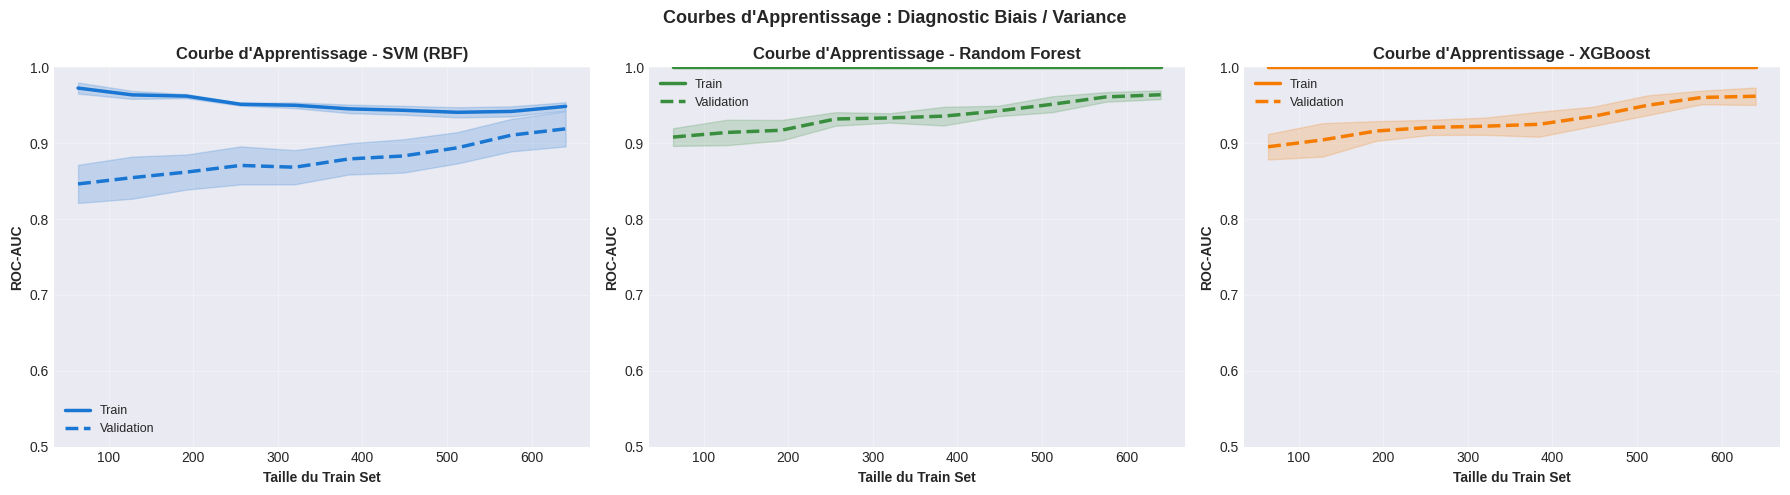

Figure 16 sauvegardée.


In [63]:
# ─── Figure 16 : Courbes d'apprentissage ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_sizes = np.linspace(0.1, 1.0, 10)

model_lc_list = [
    ('SVM (RBF)', svm_default, X_train_smote_pt, y_train_smote, '#1976D2'),
    ('Random Forest', rf_default, X_train_smote_raw, y_train_smote, '#388E3C'),
    (gb_label, gb_default, X_train_smote_raw, y_train_smote, '#F57C00')
]

for ax, (name, model, X_lc, y_lc, color) in zip(axes, model_lc_list):

    try:
        train_sz, train_scores, val_scores = learning_curve(
            model,
            X_lc,
            y_lc,
            train_sizes=train_sizes,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc',
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)

        val_mean = val_scores.mean(axis=1)
        val_std  = val_scores.std(axis=1)

        # courbe train
        ax.plot(
            train_sz,
            train_mean,
            color=color,
            linewidth=2.5,
            label='Train'
        )

        ax.fill_between(
            train_sz,
            train_mean - train_std,
            train_mean + train_std,
            alpha=0.2,
            color=color
        )

        # courbe validation
        ax.plot(
            train_sz,
            val_mean,
            linestyle='--',
            linewidth=2.5,
            color=color,
            label='Validation'
        )

        ax.fill_between(
            train_sz,
            val_mean - val_std,
            val_mean + val_std,
            alpha=0.2,
            color=color
        )

        ax.set_xlabel('Taille du Train Set', fontweight='bold')
        ax.set_ylabel('ROC-AUC', fontweight='bold')

        ax.set_title(
            f"Courbe d'Apprentissage - {name}",
            fontweight='bold'
        )

        ax.legend(fontsize=9)
        ax.set_ylim([0.5, 1.0])
        ax.grid(alpha=0.3)

    except Exception as e:

        ax.text(
            0.5,
            0.5,
            f"Erreur : {e}",
            ha='center',
            va='center',
            transform=ax.transAxes
        )

        ax.set_title(name)

plt.suptitle(
    "Courbes d'Apprentissage : Diagnostic Biais / Variance",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "fig16_learning_curves.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure 16 sauvegardée.")

### Figure 17 : Distribution des Probabilites Predites

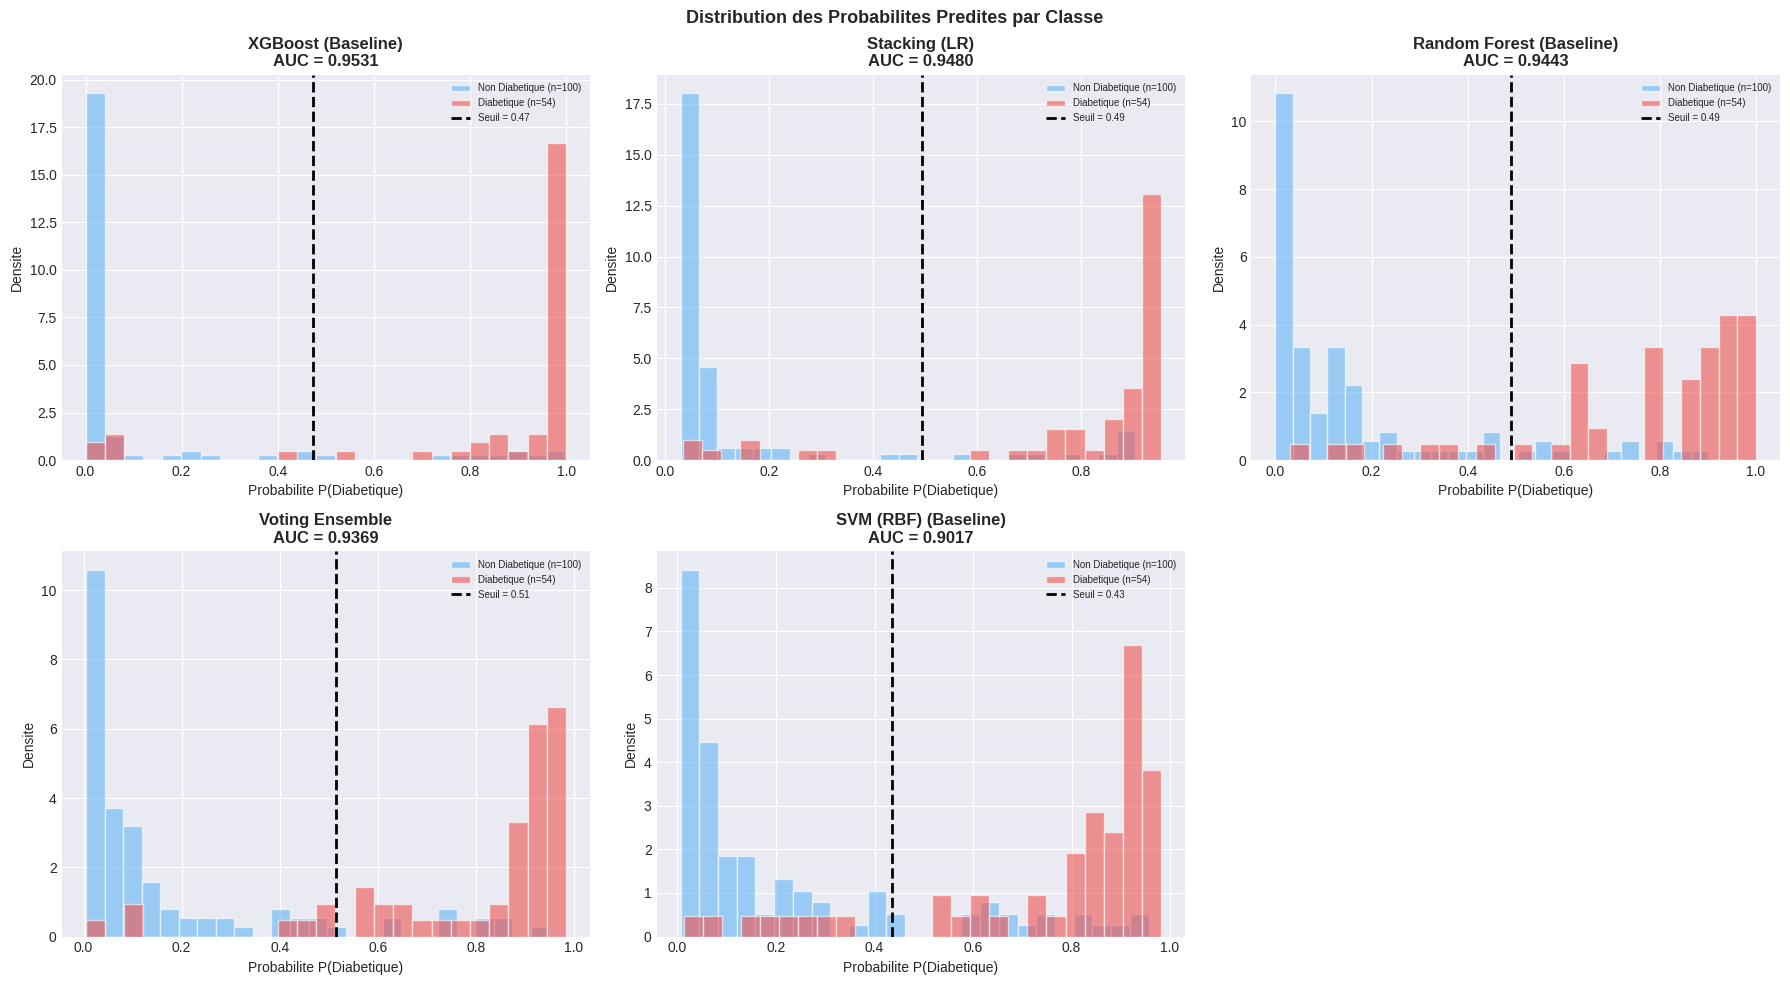

Figure 17 sauvegardee.


In [64]:
# ─── Figure 17 : Distribution des scores de probabilite par classe ───────────
# Visualise la separation des distributions p(Y=1) entre les deux classes.
# Une bonne separation (distributions eloignees) indique un bon discriminant.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, r) in enumerate(sorted_results):
    if idx >= 6:
        break
    ax = axes[idx]
    proba = r['y_proba']

    # Histogramme separe par classe reelle
    for cls, color, label in [(0, '#64B5F6', 'Non Diabetique'), (1, '#EF5350', 'Diabetique')]:
        mask_cls = (y_test == cls)
        ax.hist(proba[mask_cls], bins=25, alpha=0.6, color=color,
                label=f'{label} (n={mask_cls.sum()})', density=True, edgecolor='white')

    # Seuil optimal
    ax.axvline(r['threshold'], color='black', linestyle='--', linewidth=2,
               label=f"Seuil = {r['threshold']:.2f}")
    ax.set_title(f"{name}\nAUC = {r['auc']:.4f}", fontweight='bold')
    ax.set_xlabel('Probabilite P(Diabetique)')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=7)

# Cacher les axes inutilises
for idx in range(len(sorted_results), 6):
    axes[idx].axis('off')

plt.suptitle('Distribution des Probabilites Predites par Classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_distributions_probas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 sauvegardee.")


### Figure 18 : Tableau de Bord Final des Performances

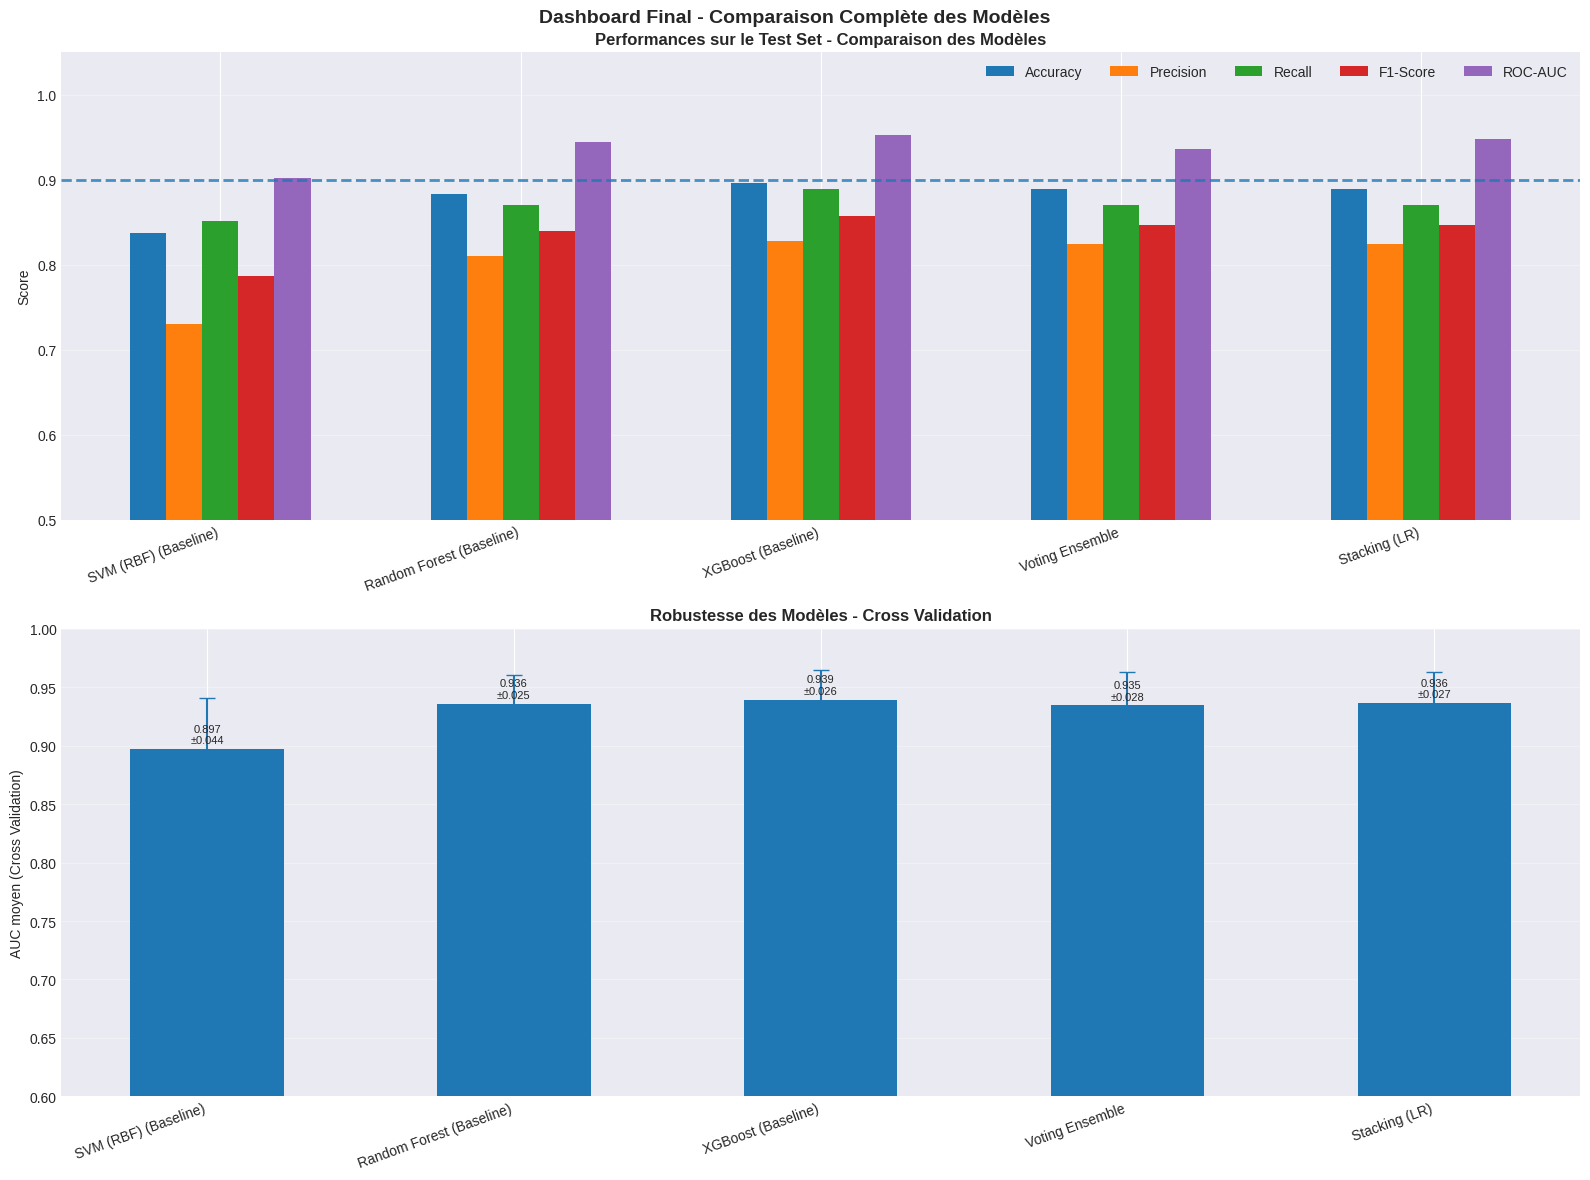

Figure 18 sauvegardée.


In [66]:
# ─── Figure 18 : Tableau de bord complet ────────────────────────────────────

# utiliser tous les modèles
all_names = list(all_results.keys())

all_acc    = [all_results[n]['accuracy']  for n in all_names]
all_prec   = [all_results[n]['precision'] for n in all_names]
all_recall = [all_results[n]['recall']    for n in all_names]
all_f1     = [all_results[n]['f1']        for n in all_names]
all_auc    = [all_results[n]['auc']       for n in all_names]
all_cv     = [all_results[n]['cv_mean']   for n in all_names]
all_cv_std = [all_results[n]['cv_std']    for n in all_names]

x = np.arange(len(all_names))
w = 0.12

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ─────────────────────────────────────────
# Sous-figure 1 : métriques Test
# ─────────────────────────────────────────

ax1 = axes[0]

ax1.bar(x - 2*w, all_acc,    w, label='Accuracy')
ax1.bar(x - w,   all_prec,   w, label='Precision')
ax1.bar(x,       all_recall, w, label='Recall')
ax1.bar(x + w,   all_f1,     w, label='F1-Score')
ax1.bar(x + 2*w, all_auc,    w, label='ROC-AUC')

ax1.set_xticks(x)
ax1.set_xticklabels(all_names, rotation=20, ha='right')

ax1.set_ylabel('Score')
ax1.set_ylim([0.5, 1.05])

ax1.set_title(
    'Performances sur le Test Set - Comparaison des Modèles',
    fontweight='bold'
)

ax1.legend(ncol=5)
ax1.grid(axis='y', alpha=0.3)

# ligne objectif
ax1.axhline(
    0.90,
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label='Objectif 90%'
)

# ─────────────────────────────────────────
# Sous-figure 2 : Cross Validation
# ─────────────────────────────────────────

ax2 = axes[1]

bars = ax2.bar(x, all_cv, width=0.5)

ax2.errorbar(
    x,
    all_cv,
    yerr=all_cv_std,
    fmt='none',
    capsize=6
)

for bar, cv, std in zip(bars, all_cv, all_cv_std):

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{cv:.3f}\n±{std:.3f}',
        ha='center',
        fontsize=8
    )

ax2.set_xticks(x)
ax2.set_xticklabels(all_names, rotation=20, ha='right')

ax2.set_ylabel('AUC moyen (Cross Validation)')
ax2.set_ylim([0.6, 1.0])

ax2.set_title(
    'Robustesse des Modèles - Cross Validation',
    fontweight='bold'
)

ax2.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────

plt.suptitle(
    'Dashboard Final - Comparaison Complète des Modèles',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'fig18_dashboard_final.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure 18 sauvegardée.")

### Figure 19 : Scatter Plots des Features les Plus Discriminantes

## 13. Conclusion


| Technique | Impact |
|-----------|--------|
| Borderline-SMOTE | Gere le desequilibre des classes de maniere ciblée |
| PowerTransformer (Yeo-Johnson) | Normalise les distributions asymetriques (Insulin, DPF) |
| Feature Engineering (8 features) | Capture des interactions non-lineaires |
| Optuna TPE (100-200 trials) | Explore l'espace des hyperparametres de maniere intelligente |
| Optimisation du seuil | Maximise le F1 sur les classes desequilibrees |

